In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import json

In [2]:
with open ('collapse_model_coef.json','r') as f:
    tmp = json.load(f)
c0, c1, c2 = tmp.get('Coefficients')
print(c0,c1,c2)

0.0031448280272491913 1.0639943583718066 -0.14261602696117176


In [3]:
ims = []
rps = [224,475,975,2475,4975,9950]
for rp in rps:
    ims.append(pd.read_csv('SanFrancisco_RP{}.csv'.format(rp),header=0,index_col=False))

In [4]:
T1 = 1.12
Ta = int(0.2*T1*100)/100
Tb = int(3*T1*100)/100

In [5]:
sa = []
saratio = []
ds = []
for i,rp in enumerate(rps):
    sa.append(ims[i].iloc[:,int(T1*100)].to_numpy()[0])
    saratio.append(ims[i].iloc[:,int(T1*100)].to_numpy()/np.exp(np.mean(np.log(ims[i].iloc[:,int(Ta*100):int(Tb*100)].to_numpy()),axis=1)))
    ds.append(ims[i].iloc[:,-1].to_numpy())

In [11]:
m_saratio = np.exp(np.mean(np.log(saratio),axis=1))
m_ds = np.exp(np.mean(np.log(ds),axis=1))
print(m_saratio)
print(m_ds)

[1.48725845 1.50254813 1.52445073 1.56298332 1.60166376 1.63746923]
[11.75232451 13.41258974 15.12262805 16.85616739 18.19203879 19.07912893]


intercept a0 = 0.4461610305489409
slope a1 = 0.07325621192571254


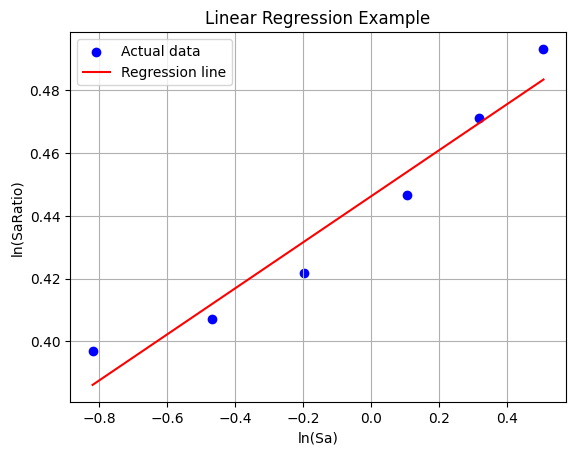

In [7]:
model_saratio = LinearRegression()
model_saratio.fit(np.log(sa).reshape(-1, 1) ,np.log(m_saratio))
a0 = model_saratio.intercept_
a1 = model_saratio.coef_[0]
print('intercept a0 = {}'.format(model_saratio.intercept_))
print('slope a1 = {}'.format(model_saratio.coef_[0]))
plt.scatter(np.log(sa), np.log(m_saratio), color='blue', label='Actual data')
plt.plot(np.log(sa), model_saratio.predict(np.log(sa).reshape(-1, 1)), color='red', label='Regression line')
plt.xlabel('ln(Sa)')
plt.ylabel('ln(SaRatio)')
plt.title('Linear Regression Example')
plt.legend()
plt.grid(True)
plt.show()

intercept b0 = 2.776055124787868
slope b1 = 0.37240051057230233


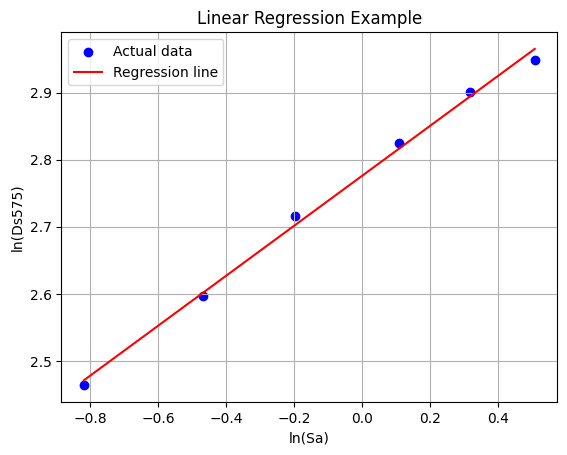

In [8]:
model_ds = LinearRegression()
model_ds.fit(np.log(sa).reshape(-1, 1) ,np.log(m_ds))
b0 = model_ds.intercept_
b1 = model_ds.coef_[0]
print('intercept b0 = {}'.format(model_ds.intercept_))
print('slope b1 = {}'.format(model_ds.coef_[0]))
plt.scatter(np.log(sa), np.log(m_ds), color='blue', label='Actual data')
plt.plot(np.log(sa), model_ds.predict(np.log(sa).reshape(-1, 1)), color='red', label='Regression line')
plt.xlabel('ln(Sa)')
plt.ylabel('ln(Ds575)')
plt.title('Linear Regression Example')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
Sa_col_50 = np.exp((c0+c1*a0+c2*b0)/(1+c1*a1+c2*b1))
print(Sa_col_50)

1.0832458247252315
